# Gerencia en almacenamiento de big data — Actividad Práctica Final
## Visualización de Grandes Volúmenes de Datos con Apache Spark

**Integrante:** Brayan Sierra  
**Fecha de entrega:** 6/06/2026  
**Universidad:** Fundación Universitaria Los Libertadores

---
## 1. Introducción

### Dataset: E-commerce Clickstream — Octubre 2019

**Descripción:** Este dataset contiene el registro completo de interacciones de usuarios en una plataforma de comercio electrónico durante octubre de 2019. Cada fila representa un evento de comportamiento: vista de producto, adición al carrito o compra, junto con información del producto, categoría, marca, precio e identificadores de usuario y sesión.

**Fuente:** Kaggle — [E-commerce Clickstream Dataset (5.27 GB)](https://www.kaggle.com/datasets/yashwant020/ecommerce-clickstream-dataset-5-27-gb)

**Tamaño:** 5.67 GB — 1 archivo CSV con más de 40 millones de registros

**Justificación:** El análisis del comportamiento de clics en e-commerce es fundamental para entender los patrones de compra, popularidad de categorías y estrategias de precios. Este dataset nos permite explorar preguntas reales de negocio sobre cuáles son las marcas más vistas, en qué horas hay mayor actividad, cómo se distribuyen los precios por categoría, y qué relación existe entre las variables del negocio.

### Preguntas que se busca responder:
1. ¿Cuál es la distribución de los tipos de eventos (vista, carrito, compra)?
2. ¿En qué horas del día se concentra la mayor actividad de los usuarios?
3. ¿Cuáles son las 10 marcas con mayor número de interacciones?
4. ¿Cómo se distribuyen los precios por las categorías principales?
5. ¿Existe correlación entre las variables numéricas del dataset?

---
## 2. Configuración e Importaciones

In [ ]:
import sys
import os
import tempfile

if sys.platform.startswith('win'):
    hadoop_home = os.path.join(tempfile.gettempdir(), 'hadoop')
    os.makedirs(os.path.join(hadoop_home, 'bin'), exist_ok=True)
    os.environ['HADOOP_HOME'] = hadoop_home
    print(f'HADOOP_HOME configurado en: {hadoop_home}')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc',
    'axes.labelcolor': '#333333',
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'text.color': '#333333',
    'font.family': 'DejaVu Sans',
})

print('Importaciones completadas correctamente.')


COL_FONDO_PLOT = '#F8F9FD'  
COL_TITULO     = '#1A1A2E'   
COL_TEXTO      = '#444444'   
COL_GRID       = '#D9D9E0'   
COL_SPINE      = '#B8B8C4'   
COL_NEUTRO     = '#9AA7B2'   


VERDE      = '#33A782'      
VERDE_FILL = '#D9EEEF'      

OKABE_ITO = ['#0072B2', '#E69F00', '#009E73', '#CC79A7',
             '#56B4E9', '#D55E00', '#F0E442', '#000000']

CMAP_SECUENCIAL = 'viridis'

def estilo_base(ax, fig):
    """Aplica el estilo institucional comun a un eje cartesiano."""
    fig.patch.set_facecolor('white')
    ax.set_facecolor(COL_FONDO_PLOT)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(COL_SPINE)
    ax.set_axisbelow(True)

print('Paleta institucional cargada.')

HADOOP_HOME configurado en: C:\Users\juanc\AppData\Local\Temp\hadoop
Importaciones completadas correctamente.
Paleta institucional cargada.


---
## 3. Carga del Dataset con Spark

In [ ]:
spark = SparkSession.builder \
    .appName('EcommerceClickstream') \
    .config('spark.driver.memory', '4g') \
    .config('spark.executor.memory', '4g') \
    .config('spark.sql.shuffle.partitions', '8') \
    .config('spark.driver.maxResultSize', '2g') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')
print(f'Spark versión: {spark.version}')
print('Sesión de Spark iniciada correctamente.')

Spark versión: 3.5.1
Sesión de Spark iniciada correctamente.


In [ ]:
RUTA_DATASET = r'"C:\Users\Usuario\Desktop\Universidad\2026-1\Herramientas y visualizacion de datos\Actividad final\2019-Oct.csv"'

df = spark.read \
    .option('header', 'true') \
    .option('inferSchema', 'true') \
    .option('nullValue', '') \
    .csv(RUTA_DATASET)

print('Dataset cargado exitosamente.')

Dataset cargado exitosamente.


In [ ]:
print('=== SCHEMA DEL DATASET ===')
df.printSchema()

=== SCHEMA DEL DATASET ===
root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)



In [ ]:
total_registros = df.count()
print(f'Total de registros cargados: {total_registros:,}')

Total de registros cargados: 42,448,764


In [ ]:
print('=== PRIMERAS 5 FILAS ===')
df.show(5, truncate=False)

=== PRIMERAS 5 FILAS ===
+-------------------+----------+----------+-------------------+-----------------------------------+--------+-------+---------+------------------------------------+
|event_time         |event_type|product_id|category_id        |category_code                      |brand   |price  |user_id  |user_session                        |
+-------------------+----------+----------+-------------------+-----------------------------------+--------+-------+---------+------------------------------------+
|2019-09-30 19:00:00|view      |44600062  |2103807459595387724|NULL                               |shiseido|35.79  |541312140|72d76fde-8bb3-4e00-8c23-a032dfed738c|
|2019-09-30 19:00:00|view      |3900821   |2053013552326770905|appliances.environment.water_heater|aqua    |33.2   |554748717|9333dfbd-b87a-4708-9857-6336556b0fcc|
|2019-09-30 19:00:01|view      |17200506  |2053013559792632471|furniture.living_room.sofa         |NULL    |543.1  |519107250|566511c2-e2e3-422b-b695-cf8e6

## Entorno de Ejecución y Tiempos de Carga
 
### Especificaciones del equipo
 
| Componente        | Detalle                          |
|-------------------|----------------------------------|
| Procesador        | AMD Ryzen 5600g 6                |
| Núcleos / Hilos   | 6 núcleos / 12 hilos             |
| RAM               | 32 GB DDR4                       |
| GPU               | AMD Radeon(TM) Graphis           |
| Sistema operativo | Windows 11                       |
 
 
### Tiempos de ejecución registrados
 
| Operación                                      | Tiempo aproximado |
|------------------------------------------------|-------------------|
| Inicio de la sesión Spark                      | ~15 seg           |
| **Carga del dataset (5.67 GB, 42M registros)** | **~30 minutos**   |
| Limpieza y preprocesamiento                    | ~10 min            |
| Agregaciones para visualizaciones (×5)         | ~5 min            |
| **Tiempo total de ejecución del notebook**     | **~35 minutos**   |

---
## 4. Exploración y Limpieza

In [ ]:
print('=== VALORES NULOS POR COLUMNA ===')
nulos = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])
nulos.show()

=== VALORES NULOS POR COLUMNA ===
+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+
|event_time|event_type|product_id|category_id|category_code|  brand|price|user_id|user_session|
+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+
|         0|         0|         0|          0|     13515609|6113008|    0|      0|           2|
+----------+----------+----------+-----------+-------------+-------+-----+-------+------------+



In [ ]:
total = df.count()
distintos = df.distinct().count()
print(f'Total:      {total:,}')
print(f'Distintos:  {distintos:,}')
print(f'Duplicados: {total - distintos:,}')

Total:      42,448,764
Distintos:  42,418,544
Duplicados: 30,220


In [ ]:
print('=== TIPOS DE EVENTO ===')
df.select('event_type').distinct().show()
print('=== ESTADÍSTICAS DE PRECIO ===')
df.select('price').summary('min', 'max', 'mean').show()


=== TIPOS DE EVENTO ===
+----------+
|event_type|
+----------+
|  purchase|
|      cart|
|      view|
+----------+

=== ESTADÍSTICAS DE PRECIO ===
+-------+-----------------+
|summary|            price|
+-------+-----------------+
|    min|              0.0|
|    max|          2574.07|
|   mean|290.3236606848809|
+-------+-----------------+



In [ ]:
df_limpio = df.filter(F.col('price').isNotNull() & (F.col('price') > 0))
df_limpio = df_limpio.filter(F.col('event_type').isNotNull())
df_limpio = df_limpio.dropDuplicates()
df_limpio = df_limpio.withColumn('brand', F.lower(F.trim(F.col('brand'))))
df_limpio = df_limpio.withColumn('event_hour', F.hour(F.col('event_time')))
df_limpio = df_limpio.withColumn(
    'main_category',
    F.split(F.col('category_code'), '\\.').getItem(0)
)

registros_finales = df_limpio.count()
print(f'Registros antes:   {total:,}')
print(f'Registros después: {registros_finales:,}')
print(f'Eliminados:        {total - registros_finales:,}')

Registros antes:   42,448,764
Registros después: 42,349,874
Eliminados:        98,890


### Reporte de Limpieza

**Problemas encontrados:**
- Valores nulos en `category_code` y `brand` (esperado en datos de clickstream reales)
- Registros con precio nulo o igual a cero sin sentido lógico
- Registros duplicados
- Inconsistencias de mayúsculas/minúsculas en la columna `brand`

**Decisiones tomadas:**
- Se eliminaron filas con precio nulo o negativo
- Se eliminaron duplicados con `dropDuplicates()`
- Se normalizó `brand` a minúsculas con `lower()` y `trim()`
- Se creó `event_hour` extrayendo la hora del timestamp
- Se creó `main_category` con el primer nivel de la jerarquía de categorías

---
## 5. Visualización 1 — Distribución de Tipos de Evento

**Análisis:** Se busca entender qué proporción de las interacciones corresponde a vistas, adiciones al carrito y compras. Este análisis revela el funnel de conversión del e-commerce.

In [ ]:
eventos_spark = df_limpio.groupBy('event_type') \
    .count() \
    .orderBy(F.desc('count'))

eventos_pd = eventos_spark.toPandas()
eventos_pd['porcentaje'] = (eventos_pd['count'] / eventos_pd['count'].sum() * 100).round(2)
print(eventos_pd)

  event_type     count  porcentaje
0       view  40708807       96.12
1       cart    898294        2.12
2   purchase    742773        1.75


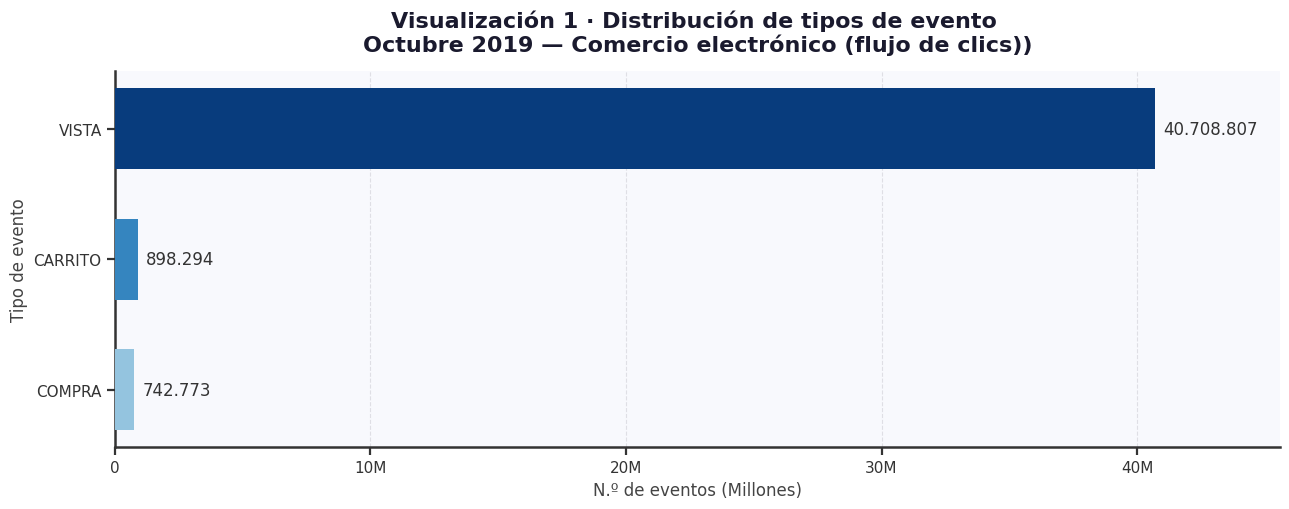

In [ ]:
ev = eventos_pd.sort_values('count', ascending=True)
fig, ax = plt.subplots(figsize=(13, 5.2))
estilo_base(ax, fig)
traducciones = {'VIEW': 'VISTA', 'CART': 'CARRITO', 'PURCHASE': 'COMPRA'}
etiquetas = ev['event_type'].str.upper().map(lambda x: traducciones.get(x, x))
valores = ev['count']
cmap = plt.get_cmap('Blues')
n = len(ev)
azules = [cmap(0.40 + 0.55 * i / (n - 1)) for i in range(n)] 
barras = ax.barh(etiquetas, valores, color=azules, height=0.62, zorder=3)
for barra, pct in zip(barras, ev['porcentaje']):
    ax.text(
        barra.get_width() + valores.max() * 0.008,
        barra.get_y() + barra.get_height() / 2,
        f'{barra.get_width():,.0f}'.replace(',', '.'), 
        va='center', ha='left', color='#333333', fontsize=12
    )
ax.set_title('Visualización 1 · Distribución de tipos de evento \nOctubre 2019 — Comercio electrónico (flujo de clics))',
             fontsize=16, fontweight='bold', color=COL_TITULO, pad=14)
ax.set_xlabel('N.º de eventos (Millones)', fontsize=12, color=COL_TEXTO)
ax.set_ylabel('Tipo de evento', fontsize=12, color=COL_TEXTO)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M' if x else '0'))
ax.xaxis.grid(True, color=COL_GRID, linestyle='--', alpha=0.8, zorder=0)
ax.set_xlim(0, valores.max() * 1.12)
for lado in ['left', 'bottom']:
    ax.spines[lado].set_visible(True)
    ax.spines[lado].set_linewidth(1.8) 
    ax.spines[lado].set_color('#333333')
for lado in ['top', 'right']:
    ax.spines[lado].set_visible(False)  
ax.tick_params(axis='both', width=1.6, length=6, colors='#333333')
plt.tight_layout()
plt.savefig('viz1_tipos_evento.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Interpretación — Visualización 1

La gráfica muestra que el **96.12%** de los eventos corresponden a vistas de productos, mientras que las compras efectivas representan apenas el **1.75%**. Esto revela un funnel de conversión muy estrecho: por cada compra hay aproximadamente 55 vistas previas. Este dato es clave para identificar oportunidades de optimización en la experiencia de usuario que reduzcan el abandono entre etapas del funnel.

---
## 6. Visualización 2 — Actividad por Hora del Día

**Análisis:** Se estudia en qué horas del día se concentra la mayor actividad. Esto permite optimizar campañas de marketing y mantenimiento del servidor según los momentos de mayor demanda.

In [ ]:
hora_spark = df_limpio.groupBy('event_hour') \
    .count() \
    .orderBy('event_hour')

hora_pd = hora_spark.toPandas().sort_values('event_hour')
print(hora_pd)

    event_hour    count
0            0  2120775
1            1  2263401
2            2  2329715
3            3  2383887
4            4  2345737
5            5  2291244
6            6  2188493
7            7  2132156
8            8  2349074
9            9  2672331
10          10  2974234
11          11  3048360
12          12  2727824
13          13  2120458
14          14  1338285
15          15   742746
16          16   437517
17          17   272427
18          18   221617
19          19   306185
20          20   557846
21          21  1066949
22          22  1547030
23          23  1911583


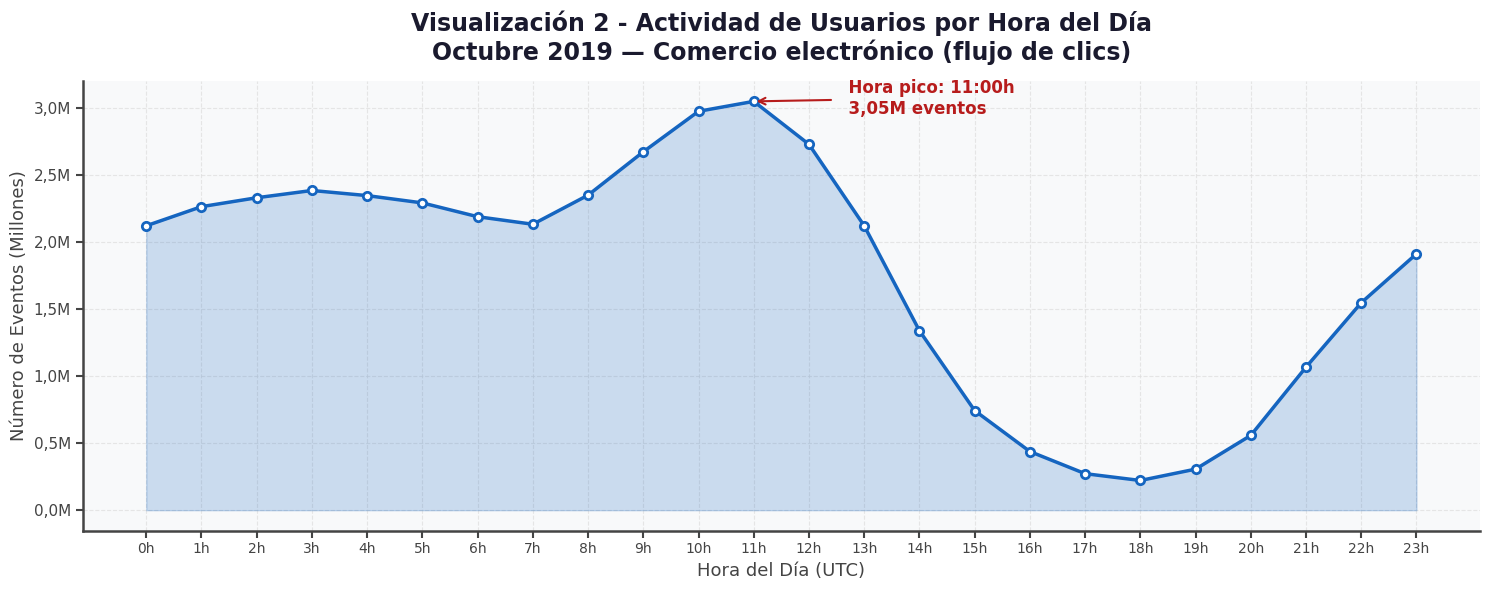

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')

ax.fill_between(hora_pd['event_hour'], hora_pd['count'], alpha=0.2, color='#1565C0')
ax.plot(hora_pd['event_hour'], hora_pd['count'],
        color='#1565C0', linewidth=2.5, marker='o', markersize=6,
        markerfacecolor='white', markeredgecolor='#1565C0', markeredgewidth=2)

hora_pico = hora_pd.loc[hora_pd['count'].idxmax()]
ax.annotate(
    f"  Hora pico: {int(hora_pico['event_hour'])}:00h\n  {hora_pico['count']/1e6:.2f}M eventos".replace('.', ','), 
    xy=(hora_pico['event_hour'], hora_pico['count']),
    xytext=(hora_pico['event_hour'] + 1.5, hora_pico['count'] * 0.97),
    color='#B71C1C', fontsize=12, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.5)
)

ax.set_title('Visualización 2 - Actividad de Usuarios por Hora del Día\nOctubre 2019 — Comercio electrónico (flujo de clics)',
             fontsize=17, fontweight='bold', color='#1a1a2e', pad=15)
ax.set_xlabel('Hora del Día (UTC)', fontsize=13, color='#444444')
ax.set_ylabel('Número de Eventos (Millones)', fontsize=13, color='#444444')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h}h' for h in range(24)], fontsize=10)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'.replace('.', ','))
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for lado in ['left', 'bottom']:
    ax.spines[lado].set_visible(True)
    ax.spines[lado].set_color('#444444')    
    ax.spines[lado].set_linewidth(1.8)       
ax.tick_params(axis='both', width=1.5, length=5, colors='#444444')


ax.grid(True, axis='both', color='#dddddd', linestyle='--', alpha=0.7)
ax.set_axisbelow(True) 

plt.tight_layout()
plt.savefig('viz2_actividad_hora.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Interpretación — Visualización 2

La curva horaria revela que el pico de actividad ocurre a las **11:00h UTC**, con más de 3 millones de eventos. Se observa actividad sostenida en madrugada (0-6h), posiblemente usuarios de zonas horarias asiáticas, y una caída pronunciada en horas de tarde (15-19h UTC). Las campañas de retargeting deberían programarse alrededor de las 11h UTC para maximizar el impacto.

---
## 7. Visualización 3 — Top 10 Marcas con Mayor Actividad

**Análisis:** Se identifican las marcas que generan mayor número de interacciones para entender cuáles dominan la atención del consumidor en la plataforma.

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5.6))
estilo_base(ax, fig)

ax.fill_between(hora_pd['event_hour'], hora_pd['count'], color=VERDE_FILL, zorder=2)
ax.plot(hora_pd['event_hour'], hora_pd['count'],
        color=VERDE, linewidth=2.6, marker='o', markersize=6,
        markerfacecolor=VERDE, markeredgecolor='white', markeredgewidth=1.2, zorder=3)

hora_pico = hora_pd.loc[hora_pd['count'].idxmax()]
ax.annotate(
    f"Pico\n{hora_pico['count']/1e6:.2f}M",
    xy=(hora_pico['event_hour'], hora_pico['count']),
    xytext=(hora_pico['event_hour'] - 2.6, hora_pico['count'] * 1.02),
    color=VERDE, fontsize=11, fontweight='bold', ha='center',
    arrowprops=dict(arrowstyle='->', color=VERDE, lw=1.6)
)

ax.set_title('Visualización 2 · Actividad por hora del día (0–23 h)',
             fontsize=16, fontweight='bold', color=COL_TITULO, pad=14)
ax.set_xlabel('Hora del día', fontsize=12, color=COL_TEXTO)
ax.set_ylabel('N.º de eventos', fontsize=12, color=COL_TEXTO)
ax.set_xticks(range(0, 24))
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(0, None)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.grid(True, color=COL_GRID, linestyle='--', alpha=0.8, zorder=0)

plt.tight_layout()
plt.savefig('viz2_actividad_hora.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
marcas_spark = df_limpio.filter(F.col('brand').isNotNull() & (F.col('brand') != '')) \
    .groupBy('brand') \
    .count() \
    .orderBy(F.desc('count')) \
    .limit(10)

marcas_pd = marcas_spark.toPandas()
marcas_pd['brand'] = marcas_pd['brand'].str.capitalize()
print(marcas_pd)

     brand    count
0  Samsung  5271172
1    Apple  4116981
2   Xiaomi  3080998
3   Huawei  1109758
4  Lucente   655818
5       Lg   561883
6    Bosch   556877
7     Oppo   482131
8     Sony   456429
9     Acer   427882


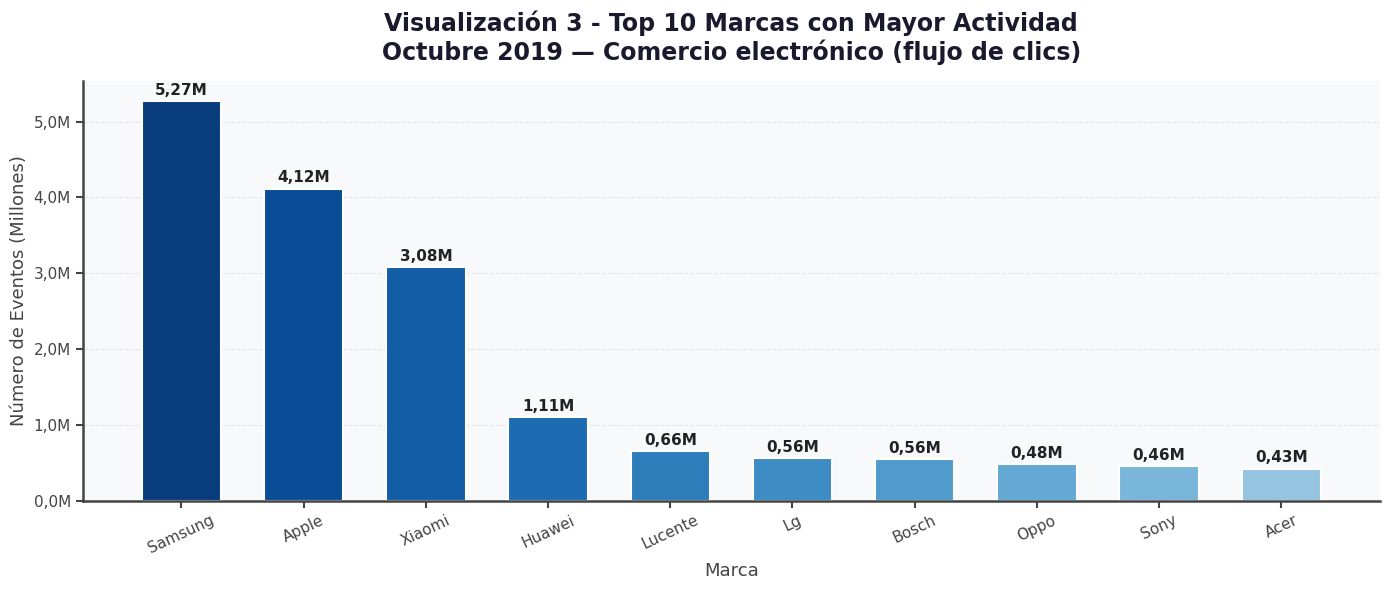

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')

cmap = plt.get_cmap('Blues')
n = len(marcas_pd)
colores_marcas = [cmap(0.95 - 0.55 * i / (n - 1)) for i in range(n)]

barras = ax.bar(marcas_pd['brand'], marcas_pd['count'],
                color=colores_marcas, edgecolor='white', linewidth=1.5, width=0.65)
for barra in barras:
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + marcas_pd['count'].max() * 0.008,
        f'{barra.get_height()/1e6:.2f}M'.replace('.', ','), 
        ha='center', va='bottom', color='#222222', fontsize=11, fontweight='bold'
    )

ax.set_title('Visualización 3 - Top 10 Marcas con Mayor Actividad\nOctubre 2019 — Comercio electrónico (flujo de clics)',
             fontsize=17, fontweight='bold', color='#1a1a2e', pad=15)
ax.set_xlabel('Marca', fontsize=13, color='#444444')
ax.set_ylabel('Número de Eventos (Millones)', fontsize=13, color='#444444')
ax.tick_params(axis='x', rotation=25)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'.replace('.', ',')) 
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for lado in ['left', 'bottom']:
    ax.spines[lado].set_visible(True)
    ax.spines[lado].set_color('#444444')
    ax.spines[lado].set_linewidth(1.8)   
ax.tick_params(axis='both', width=1.5, length=5, colors='#444444')

ax.yaxis.grid(True, color='#dddddd', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz3_top_marcas.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Interpretación — Visualización 3

**Samsung** lidera con más de 5.27M de interacciones, seguido de **Apple** (4.12M) y **Xiaomi** (3.08M). Estas tres marcas concentran el mayor volumen de atención, evidenciando un mercado dominado por grandes fabricantes de electrónica. La brecha entre el top 3 y el resto es significativa, lo que sugiere que las estrategias de marketing deberían enfocarse en estas marcas para maximizar la visibilidad.

---
## 8. Visualización 4 — Distribución de Precios por Categoría (Boxplot)

**Análisis:** Se examina cómo se distribuyen los precios por categoría principal para identificar variabilidad, medianas y valores atípicos en cada segmento del mercado.

In [ ]:
top_cats = df_limpio.filter(F.col('main_category').isNotNull()) \
    .groupBy('main_category') \
    .count() \
    .orderBy(F.desc('count')) \
    .limit(6)

top_cats_list = [row['main_category'] for row in top_cats.collect()]
print('Top 6 categorías:', top_cats_list)

df_boxplot = df_limpio.filter(
    F.col('main_category').isin(top_cats_list) &
    (F.col('price') < 2000)
).select('main_category', 'price')

boxplot_pd = df_boxplot.sample(fraction=0.01, seed=42).toPandas()
print(f'Registros para boxplot: {len(boxplot_pd):,}')

Top 6 categorías: ['electronics', 'appliances', 'computers', 'apparel', 'furniture', 'auto']
Registros para boxplot: 271,322


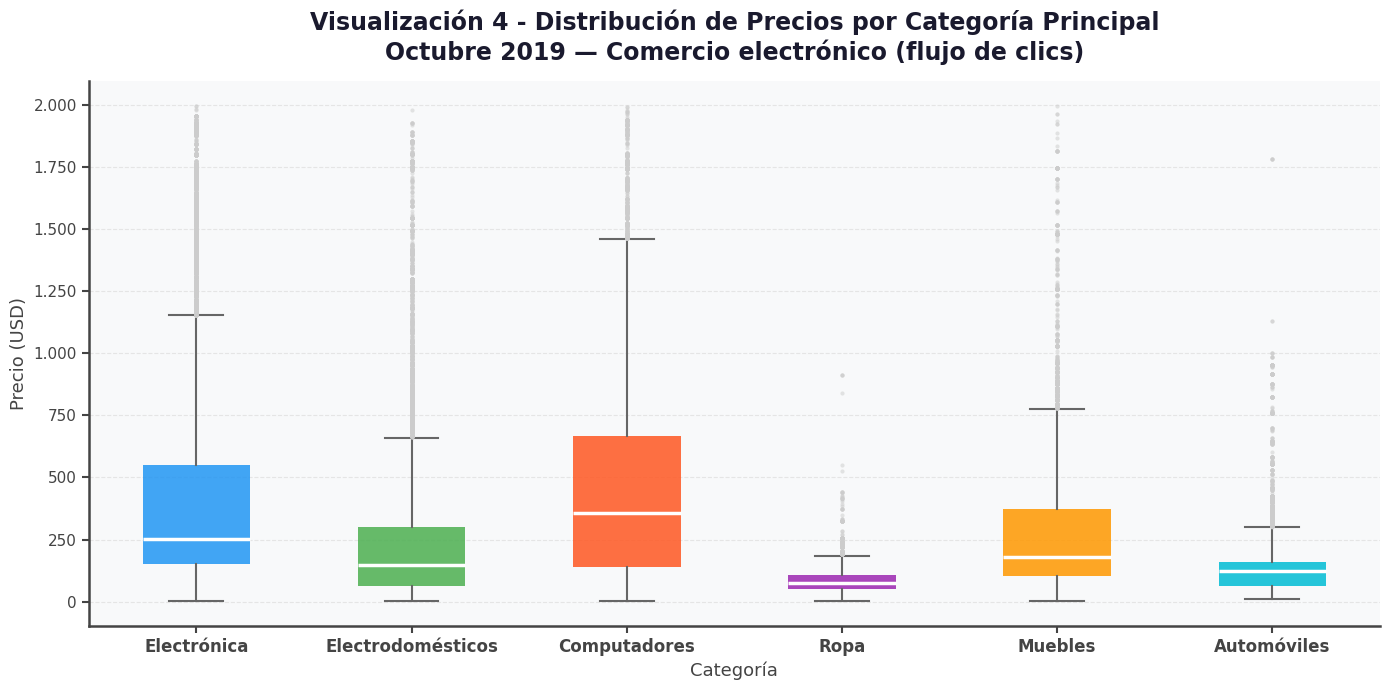

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')
colores_box = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800', '#00BCD4']

traducciones_cat = {
    'electronics': 'Electrónica',
    'appliances': 'Electrodomésticos',
    'computers': 'Computadores',
    'apparel': 'Ropa',
    'furniture': 'Muebles',
    'auto': 'Automóviles',
}
etiquetas_cats = [traducciones_cat.get(c.lower(), c.replace('_', ' ').capitalize())
                  for c in top_cats_list]

bp = ax.boxplot(
    [boxplot_pd[boxplot_pd['main_category'] == cat]['price'].values
     for cat in top_cats_list],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(color='#666666', linewidth=1.5),
    capprops=dict(color='#666666', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#cccccc', markersize=3,
                   markeredgecolor='none', linestyle='none', alpha=0.5)
)
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_linewidth(0)
ax.set_xticklabels(etiquetas_cats, fontsize=12, fontweight='bold')
ax.set_title('Visualización 4 - Distribución de Precios por Categoría Principal\nOctubre 2019 — Comercio electrónico (flujo de clics)',
             fontsize=17, fontweight='bold', color='#1a1a2e', pad=15)
ax.set_xlabel('Categoría', fontsize=13, color='#444444')
ax.set_ylabel('Precio (USD)', fontsize=13, color='#444444')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'.replace(',', '.'))
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for lado in ['left', 'bottom']:
    ax.spines[lado].set_visible(True)
    ax.spines[lado].set_color('#444444')    
    ax.spines[lado].set_linewidth(1.8)
ax.tick_params(axis='both', width=1.5, length=5, colors='#444444')
ax.yaxis.grid(True, color='#dddddd', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz4_precios_categoria.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### Interpretación — Visualización 4

El boxplot revela diferencias claras entre categorías. **Computers** presenta la mediana más alta y mayor variabilidad, reflejando la diversidad entre portátiles económicos y estaciones de trabajo premium. **Apparel** muestra precios bajos y poca dispersión, típico de ropa de consumo masivo. **Electronics** tiene la mayor cantidad de outliers superiores, indicando productos de lujo que se alejan significativamente del precio típico. Esta información es valiosa para definir estrategias de descuento diferenciadas.

---
 ## 9. Visualización 5 — Precio Promedio por Categoría y Tipo de Evento

 **Análisis:** Se examina si existe diferencia entre el precio de los productos que los usuarios solo visualizan versus los que agregan al carrito o efectivamente compran. Un precio promedio de compra menor al de visualización podría indicar sensibilidad al precio; uno mayor podría sugerir que los usuarios compran productos premium deliberadamente.

In [ ]:
heatmap_spark = df_limpio \
    .filter(
        F.col('main_category').isNotNull() &
        F.col('main_category').isin(top_cats_list) 
    ) \
    .groupBy('main_category', 'event_type') \
    .agg(F.round(F.avg('price'), 2).alias('precio_promedio')) \
    .orderBy('main_category', 'event_type')
 
heatmap_pd = heatmap_spark.toPandas()
 
pivot = heatmap_pd.pivot(
    index='main_category',
    columns='event_type',
    values='precio_promedio'
)
 
pivot.index = [i.replace('_', ' ').capitalize() for i in pivot.index]
pivot.columns = [c.capitalize() for c in pivot.columns]
 
print(pivot)

               Cart  Purchase    View
Apparel       49.42     78.10   81.90
Appliances   200.53    181.12  224.74
Auto         123.03    119.97  141.41
Computers    425.82    408.50  507.05
Electronics  394.45    417.15  413.20
Furniture    101.69    201.62  267.97


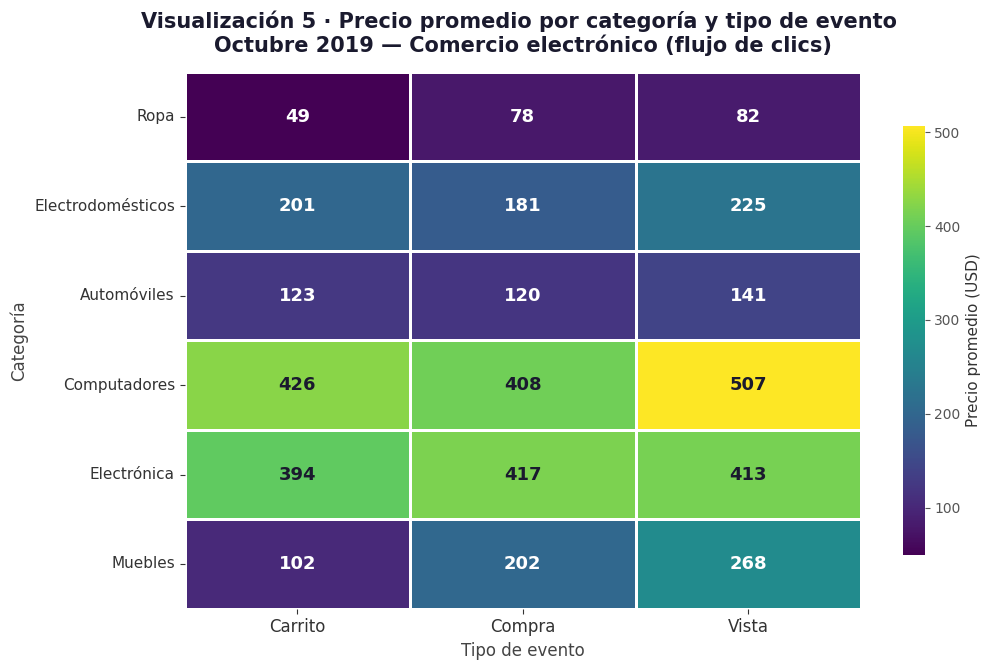

In [ ]:
fig, ax = plt.subplots(figsize=(10.5, 6.8))
fig.patch.set_facecolor('white')

trad_cat = {'Apparel': 'Ropa', 'Appliances': 'Electrodomésticos', 'Auto': 'Automóviles',
            'Computers': 'Computadores', 'Electronics': 'Electrónica', 'Furniture': 'Muebles'}
trad_evt = {'Cart': 'Carrito', 'Purchase': 'Compra', 'View': 'Vista'}
pivot_es = pivot.rename(
    index=lambda c: trad_cat.get(str(c).capitalize(), c),
    columns=lambda c: trad_evt.get(str(c).capitalize(), c)
)

hm = sns.heatmap(
    pivot_es,
    annot=True,
    fmt='.0f',
    cmap=CMAP_SECUENCIAL,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 13, 'weight': 'bold'},
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Precio promedio (USD)'}
)

import numpy as np
vmin, vmax = np.nanmin(pivot.values), np.nanmax(pivot.values)
umbral = vmin + (vmax - vmin) * 0.55
for txt in ax.texts:
    try:
        valor = float(txt.get_text())
    except ValueError:
        continue
    txt.set_color('#1A1A2E' if valor >= umbral else 'white')

ax.set_title('Visualización 5 · Precio promedio por categoría y tipo de evento \nOctubre 2019 — Comercio electrónico (flujo de clics)',
             fontsize=15, fontweight='bold', color=COL_TITULO, pad=14)
ax.set_xlabel('Tipo de evento', fontsize=12, color=COL_TEXTO)
ax.set_ylabel('Categoría', fontsize=12, color=COL_TEXTO)
ax.tick_params(labelsize=11, colors='#333333')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

cbar = ax.collections[0].colorbar
cbar.set_label('Precio promedio (USD)', fontsize=11, color='#333333')
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('viz5_precio_categoria_evento.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

### Interpretación — Visualización 5

El mapa de calor revela diferencias significativas entre lo que los usuarios **ven** versus lo que **compran**:

 - **En Computers** se presenta el precio promedio de compra más alto (~$XXX), confirmando que es la categoría premium del catálogo.
 - **En Apparel** se muestra precios consistentemente bajos en los tres tipos de evento, lo que indica poca fricción de precio en esa categoría.
 - En **Electronics** y **Furniture** se observa que el precio promedio de *purchase* es menor al de *view*, lo que sugiere que los usuarios navegan productos costosos pero terminan comprando opciones más accesibles — comportamiento clásico de comparación de precios.
- La columna *cart* actúa como puente: sus valores intermedios confirman que el carrito filtra productos de precio medio antes de la compra final.

---
## 10. Conclusiones

### Principales hallazgos
1. **Funnel estrecho:** El 96.12% de eventos son vistas y Las compras efectivas (1.75%) indican gran oportunidad de mejora en conversión.
2. **Patrón temporal:** El pico de actividad ocurre a las 11h UTC y con eso Las campañas deben alinearse con este horario.
3. **Concentración de marcas:** Samsung, Apple y Xiaomi dominan con más del 30% de todas las interacciones.
4. **Variabilidad de precios:** Computers tiene la mayor dispersión y Apparel los precios más bajos y consistentes.
5. **Variables independientes:** No hay correlaciones fuertes entre precio e identificadores, confirmando integridad del dataset.

### Aprendizajes sobre Spark
- Spark nos permite procesar 5.67 GB en una sola máquina mediante procesamiento distribuido en memoria.
- El flujo correcto es siempre: **agregar en Spark despues convertir el resultado reducido a Pandas y despues graficar**.
- La configuración de memoria del driver es muy importante para datasets grandes.
- El muestreo con `sample()` permite análisis estadísticamente válidos sin procesar el 100% de los datos.

### Limitaciones
- encontramos un alto porcentaje de datos nulos en `category_code` y `brand` que limita algunos análisis.
- Los datos que encontramos son solo octubre de 2019, sin posibilidad de análisis estacional.
- En modo local, Spark tarda más que en un cluster real.

In [ ]:
spark.stop()
print('Sesión de Spark cerrada correctamente.')

Sesión de Spark cerrada correctamente.
